# TUGAS AKHIR XII RPL | PYTHON REGRESION LINEAR | SMK PGRI 3 MALANG

METODE YANG AKAN DIGUNAKAN UNTUK KLASIFIKASI : Linear Regresion
DATASETS_PATH : 'datasets\Student lifestyle data.csv'

# DATA PREPARATION | MODUL A

IMPORT LIBARY 

In [10]:
import pandas as pd  # Libary pandas untuk memanipulasi data pada csv 
import numpy as np # Libary numpy untuk penanganan komputasi numerik 
import matplotlib.pyplot as plt # Libary matplotlib untuk visualisasi data 
import seaborn as sns # Libary seaborn untuk visualisasi data 
import tkinter as tk # Import libary tkinter untuk GUI dan implementasi uji coba data

In [11]:
data_path = "datasets/Student lifestyle data.csv" # Membuat variable untuk menuju ke path dataset disimpan

df = pd.read_csv(data_path) # Menggunakan fungsi pandas pd.read_csv untuk membaca datasets dari variable yang menuju ke dataset disimpan
# Variable "df" mewakili dataset yang sudah siap di manipulasi datanya 
df.head() # Menampilkan 5 data teratas dari dataset

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,1001,22.0,Female,Science,NaN,7.3,3.3,3.4,114.0,5.0
1,1002,20.0,Male,Engineering,2.72,5.5,7.2,6.0,NaN,2.0
2,1003,20.0,Male,Medical,NaN,5.4,2.3,1.8,137.0,3.0
3,1004,21.0,Male,Engineering,3.63,8.1,2.0,4.6,130.0,3.0
4,1005,19.0,Male,Arts,3.14,6.8,2.6,4.3,4.0,6.0


In [12]:
print('Show info type data dari datasets \n')
df.info() # Menggunakan fungsi df info untuk melihat tipe data apa saja yang terdapat pada dataset 

Show info type data dari datasets 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 98000 non-null   float64
 2   Gender              98000 non-null   object 
 3   Department          98000 non-null   object 
 4   CGPA                98000 non-null   float64
 5   Sleep_Duration      98000 non-null   float64
 6   Study_Hours         98000 non-null   float64
 7   Social_Media_Hours  98000 non-null   float64
 8   Physical_Activity   98000 non-null   float64
 9   Stress_Level        98000 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 7.6+ MB


In [13]:
shape = df.shape # Menggunakan fungsi df.shape untuk melihat dimensi data setelah data di load dan sebelum data masuk ke proses preparation
print(f"Dimensi dari data sebelum masuk proses data preparation : {shape}")

Dimensi dari data sebelum masuk proses data preparation : (100000, 10)


In [14]:
print('Show info type data dari datasets \n')

df.describe() # Melihat deskripsi dari setiap data pada dataset

Show info type data dari datasets 



,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000
mean,51000.500000,21.009020,2.897737,6.994409,4.510430,3.503534,74.354439,4.131745
std,28867.657797,2.000311,0.532342,1.498520,1.976138,1.486421,43.363699,1.424681
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


DATA PREPARATION (PROSES MENANGANI DATA DUPLIKAT SERTA DATA KOSONG)

In [15]:
# Membuat fungsi untuk menghitung missing value dan duplicated value pada dataset 
count_duplicated = df.duplicated().sum() 
count_isna = df.isna().sum().sum()

print(f"Jumlah data duplikat :  {count_duplicated}")
print(f"Jumlah data kosong : {count_isna}")

Jumlah data duplikat :  0
Jumlah data kosong : 18000


# Melihat jumlah missing value pada setiap kolom

In [16]:
# Melihat berapa jumlah missing value pada setiap kolom
print('Checking data nan/kosong/missing value dari setiap columns')
print(df.isna().sum())

Checking data nan/kosong/missing value dari setiap columns
Student_ID               0
Age                   2000
Gender                2000
Department            2000
CGPA                  2000
Sleep_Duration        2000
Study_Hours           2000
Social_Media_Hours    2000
Physical_Activity     2000
Stress_Level          2000
dtype: int64


# Function untuk menangani data kosong atau missing value

In [17]:
# Membuat metode penanganan untuk missing value 
if count_isna > 0:
    print('menangani data dengan missing value')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    object_cols = df.select_dtypes(exclude=[np.number]).columns

    for col in object_cols:
        print('data dengan tipe string sudah di tangani')
        df[col] = df[col].fillna(df[col].mode()[0])

    for col in numeric_cols:
        print('data dengan tipe numerik sudah di tangani')
        data_mean = np.around(df[col].mean())
        df[col] = df[col].fillna(data_mean)

else : 
    print("Tidak ada data yang perlu ditangani")

menangani data dengan missing value
data dengan tipe string sudah di tangani
data dengan tipe string sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani
data dengan tipe numerik sudah di tangani


In [18]:
df = df.drop_duplicates() # Meskipun data duplikat 0 tetap dilakukan metode drop_duplicates agar memastikan benar-benar tidak ada data duplikat

In [19]:
df = df.drop(columns=['Student_ID']) # Kami melakukan drop pada column student_id karena tidak menambahkan informasi pada algoritma serta tidak memiliki korelasi dengan data lainya 

MAPPING DATA DENGAN TIPE STRING

In [20]:
col_string = []

for col in df.columns:
    if df[col].dtype == 'str':
        col_string.append(col)

print('Column bertipe String Adalah')
print(f'{col_string} \n')

print('Checking Data Unique Pada Data Yang akan di mappping')
for col in col_string:
    col_unique = df[col].unique()
    print(col_unique)

# mapping section
df['Gender'] = df['Gender'].replace({
    'Male': 0,
    'Female': 1
})

df['Department'] = df['Department'].replace({
    "Science": 0,
    "Engineering": 1,
    "Medical": 2,
    "Arts": 3,
    "Business": 4
})

print(f'checking data setelah mapping data')

Column bertipe String Adalah
[] 

Checking Data Unique Pada Data Yang akan di mappping
checking data setelah mapping data


C:\Users\USER\AppData\Local\Temp\ipykernel_7196\3704012860.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({
C:\Users\USER\AppData\Local\Temp\ipykernel_7196\3704012860.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Department'] = df['Department'].replace({


In [21]:
# checking data after mapping
print('Show 5 data teratas')
df.head(5)

Show 5 data teratas


,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,22.0,1,0,3.00,7.3,3.3,3.4,114.0,5.0
1,20.0,0,1,2.72,5.5,7.2,6.0,74.0,2.0
2,20.0,0,2,3.00,5.4,2.3,1.8,137.0,3.0
3,21.0,0,1,3.63,8.1,2.0,4.6,130.0,3.0
4,19.0,0,3,3.14,6.8,2.6,4.3,4.0,6.0


In [22]:
# Mengecek dimensi data setelah data dengan missing value ditangani 
shape = df.shape
print(f"Dimensi data setelah data kosong / missing value ditangani : {shape}")

Dimensi data setelah data kosong / missing value ditangani : (100000, 9)


In [23]:
# Melihat table data setelah proses data preparation dan mapping variable string

print('show 10 data teratas \n')

df.head(10) # Menampilkan 10 Data Teratas
# Informasi perubahan kolom dengan variable string setelah di mapping
# Gender 1 : Perempuan , 0 : Laki-Laki 
# Departement Science : 0, Engineering : 1, Medical : 2, Arts : 3, Bussines : 4

show 10 data teratas 



,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,22.0,1,0,3.00,7.3,3.3,3.4,114.0,5.0
1,20.0,0,1,2.72,5.5,7.2,6.0,74.0,2.0
2,20.0,0,2,3.00,5.4,2.3,1.8,137.0,3.0
3,21.0,0,1,3.63,8.1,2.0,4.6,130.0,3.0
4,19.0,0,3,3.14,6.8,2.6,4.3,4.0,6.0
5,22.0,1,2,3.31,6.5,3.5,4.1,129.0,2.0
6,18.0,0,0,2.14,4.4,4.0,3.1,73.0,8.0
7,18.0,0,1,3.27,7.0,3.4,7.6,68.0,4.0
8,21.0,0,4,2.71,4.8,8.6,0.3,82.0,5.0
9,24.0,0,1,3.36,5.7,1.5,3.7,59.0,3.0


# EXPLORATORY DATA ANALYS | MODUL A 

Membuat statistik deskriptif untuk melihat jumlah data pada setiap kolom

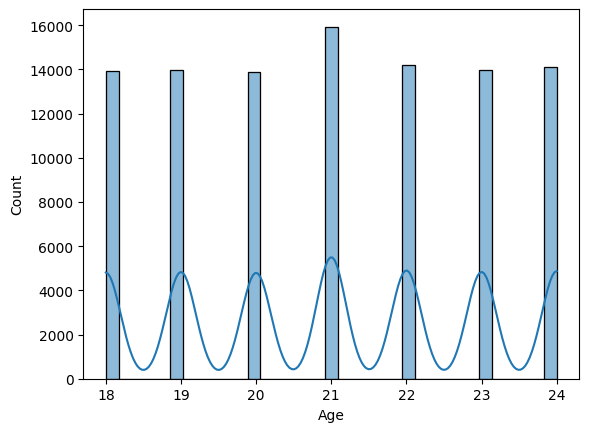

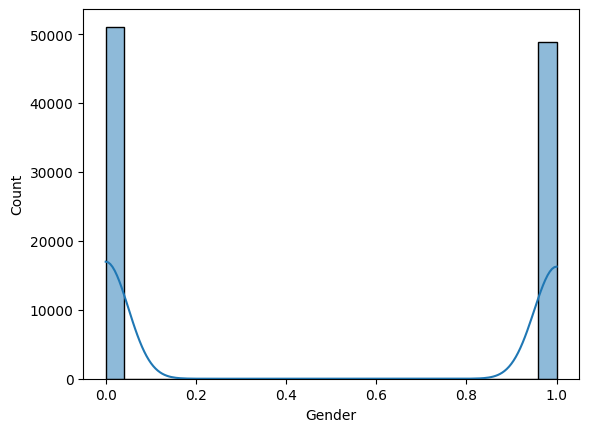

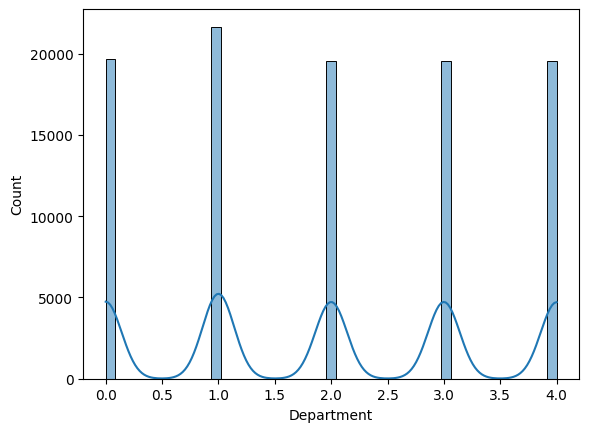

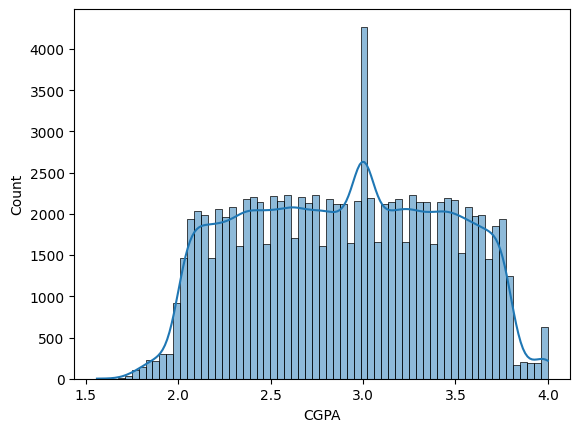

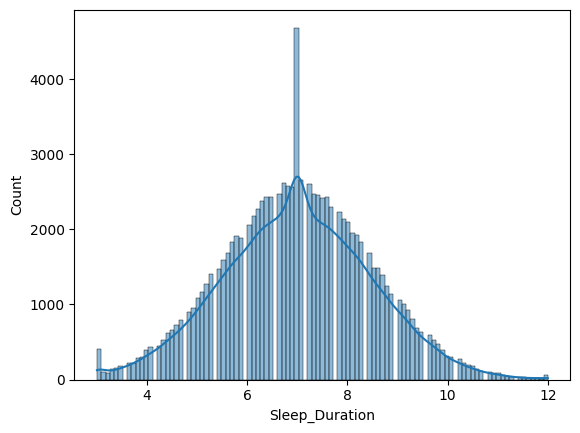

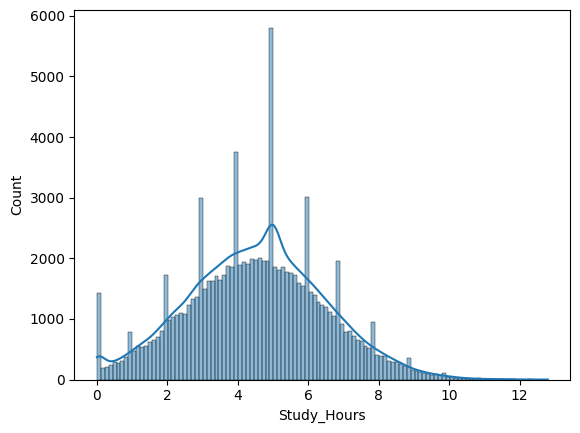

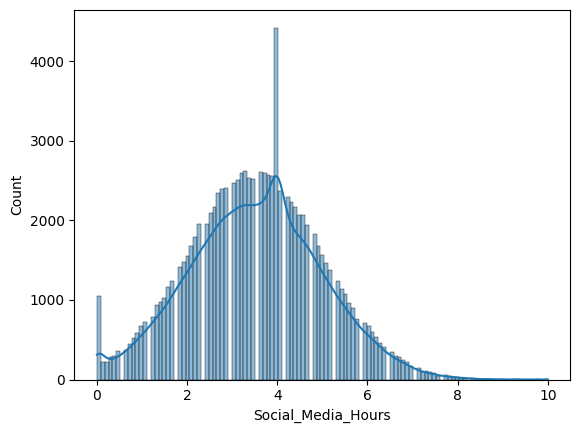

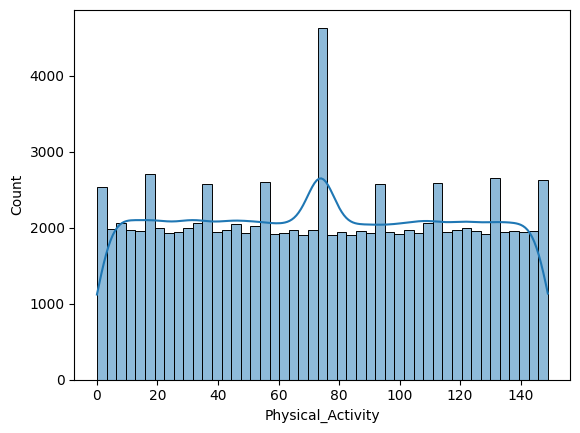

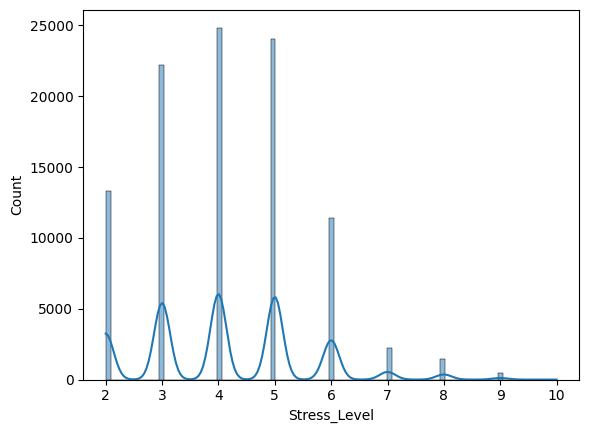

In [24]:
# Membuat statistik deskriptif untuk melihat jumlah data pada setiap kolom
for i in df.columns:
    sns.histplot(data=df[i], kde=True)
    plt.show()

# Membuat heatmap untuk melihat korelasi data mana yang berpengaruh terhadap stress level

<Axes: title={'center': 'Heatmap korelasi antar setiap data pada kolom numerik'}>

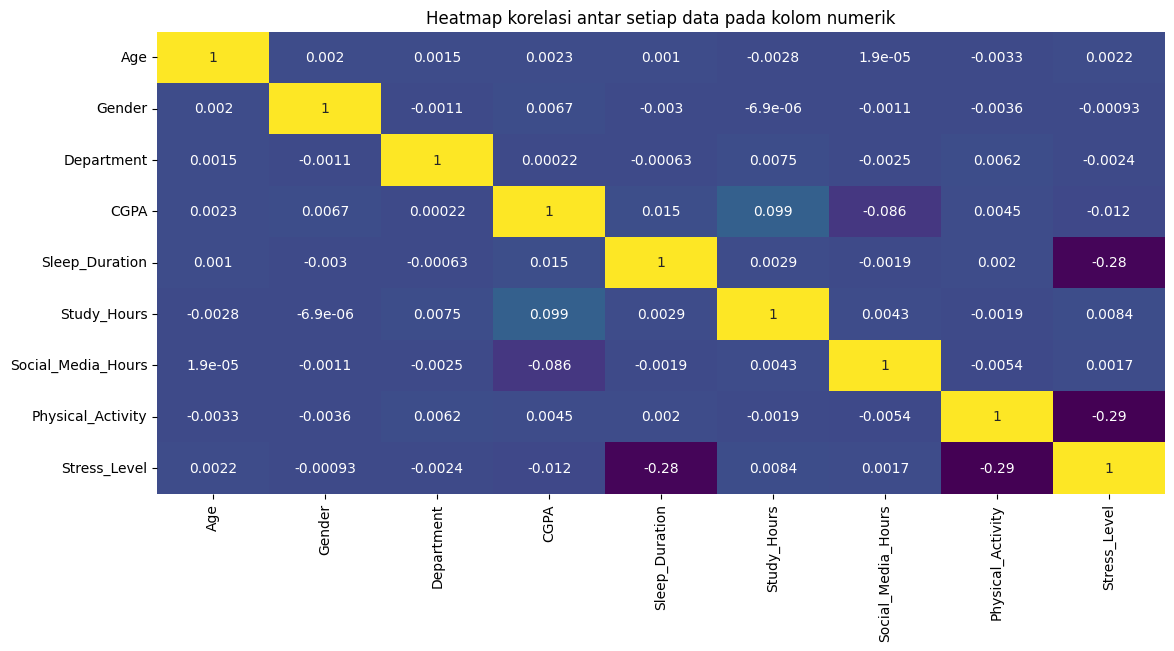

In [25]:
plt.figure(figsize=(13, 6))
plt.title("Heatmap korelasi antar setiap data pada kolom numerik")
sns.heatmap(df.corr(), annot=True, cmap='viridis', cbar=False)

<Axes: title={'center': 'Pengaruh aktifitas fisik terhadap stress level'}, xlabel='Stress_Level', ylabel='Physical_Activity'>

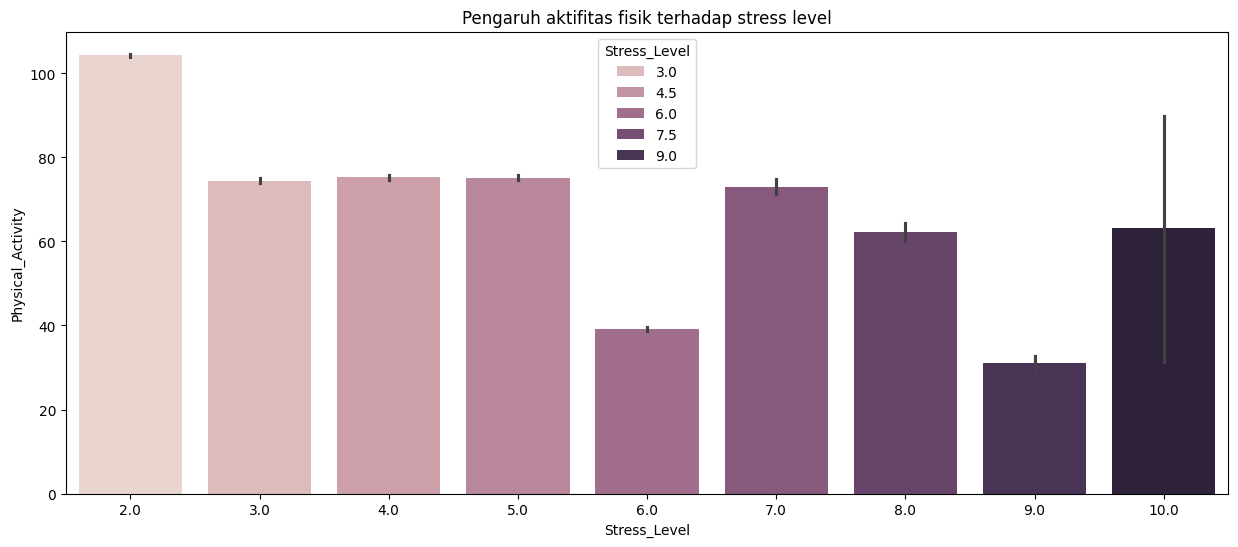

In [26]:
# Pengaruh social media hours terhadap stress level 
plt.figure(figsize=(15, 6))
plt.title("Pengaruh aktifitas fisik terhadap stress level")
sns.barplot(data=df, x='Stress_Level', y='Physical_Activity', hue='Stress_Level')

<Axes: title={'center': 'Pengaruh durasi tidur terhadap stress level'}, xlabel='Stress_Level', ylabel='Sleep_Duration'>

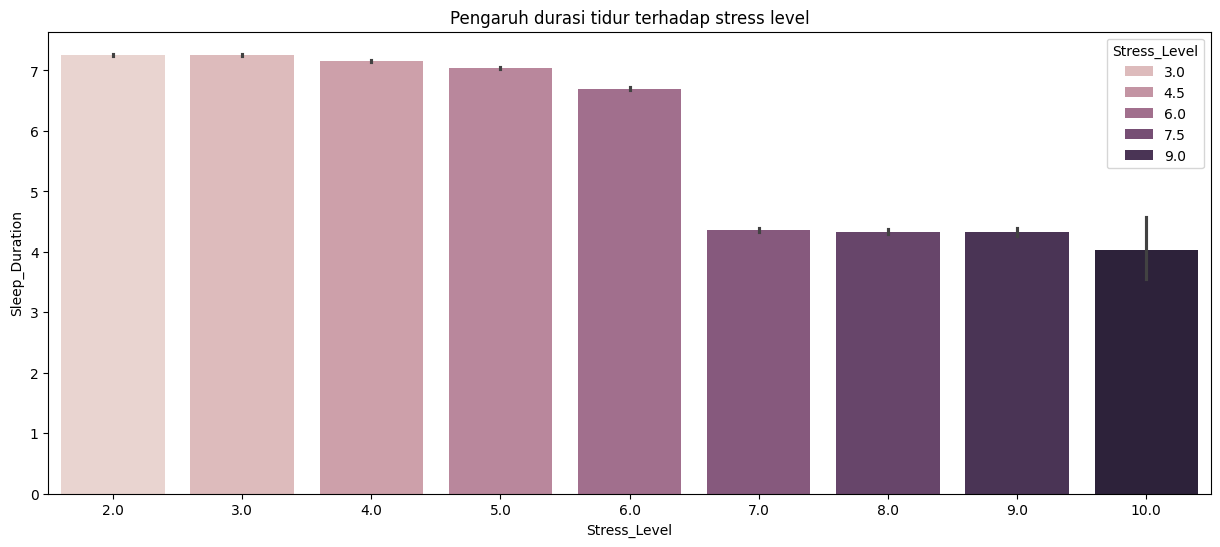

In [27]:
# Pengaruh social media hours terhadap stress level 
plt.figure(figsize=(15, 6))
plt.title("Pengaruh durasi tidur terhadap stress level")
sns.barplot(data=df, x='Stress_Level', y='Sleep_Duration', hue='Stress_Level')

Berdasarkan data data dari heatmap kami menyimpulkan data 2 yang paling berpengaruh pada stress level adalah durasi tidur atau Sleep_Duration dan juga Physical_Activity atau aktifitas fisik yang memiliki pengaruh paling signifikan terhadap stress level, berdasarkan insight yang kami buat pada data pengaruh aktifitas fisik dengan stress level dapat dilihat jika orang dengan aktifitas fisik yang minimum cenderung memilikis tress level yang lebih tinggi sama hal-nya dengan waktu tidur, orang dengan waktu tidur yang minimal cenderung memiliki stress level di tingkatan angka 7 - 10

# MODUL B | DATA CLASSIFICATION MENGGUNAKAN ALGORITMA LINEAR REGRESION

DATA TRAIN DAN TEST SECTION

In [28]:
x_col = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity'] # diisi dengan data yang akan digunakan untuk memprediksi kan hasil dari komputasi Linear
target = 'Stress_Level' # target columns

def test_train_split(data, test_size = 0.2, random_state = 42, target_columns = target, usecol = x_col):
    test_data = data.sample(frac = test_size, random_state = random_state)
    train_data = data.drop(test_data.index)

    X_train = train_data.drop(columns=[target_columns])
    X_test = test_data.drop(columns=[target_columns])

    if usecol != []:
        X_train = X_train[usecol]
        X_test = X_test[usecol]

    y_train = train_data[target_columns]
    y_test = test_data[target_columns]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = test_train_split(df)

print('Checking Dimension Dari Data Yang Sudah di split')
print(f'Data X_train {X_train.shape}')
print(f'Data X_test {X_test.shape}')
print(f'Data y_train {y_train.shape}')
print(f'Data y_test {y_test.shape}')

Checking Dimension Dari Data Yang Sudah di split
Data X_train (80000, 4)
Data X_test (20000, 4)
Data y_train (80000,)
Data y_test (20000,)


NORMALISASI SECTION

In [29]:
X_MIN = X_train.min()
X_MAX = X_train.max()

def normalisasi_numerik(X, xmin = X_MIN, xmax = X_MAX):
    x1 = X - xmin
    x2 = xmax - xmin
    
    return (x1 / x2)

In [30]:
print(X_train[:5])
X_train = normalisasi_numerik(X_train)
X_test = normalisasi_numerik(X_test)

   Sleep_Duration  Study_Hours  Social_Media_Hours  Physical_Activity
0             7.3          3.3                 3.4              114.0
1             5.5          7.2                 6.0               74.0
2             5.4          2.3                 1.8              137.0
3             8.1          2.0                 4.6              130.0
4             6.8          2.6                 4.3                4.0


In [31]:
# checking data after normalisasi
print('show 5 data teratas setelah normalisasi')
X_train[:5]

show 5 data teratas setelah normalisasi


,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity
0,0.477778,0.257812,0.34,0.765101
1,0.277778,0.562500,0.60,0.496644
2,0.266667,0.179687,0.18,0.919463
3,0.566667,0.156250,0.46,0.872483
4,0.422222,0.203125,0.43,0.026846


CORE FUNCTION ALGORITMA LINEAR REGERSION

In [32]:
class LinearRegresion:
    def __init__(self, learn_r = 0.01, iters = 14000): # init variable awal
        self.learn_r = learn_r # init learn_r sebagai acuan belajar model semakin besar maka proses belajar semakin cepat tapi datanya banyak yang terlompati, semakin kecil proses belajar semakin detail namun jika terlalu kecil maka model akan train terlalu lama, learn_rate paling umum yang di gunakan adalah 1, 0.1, 0.001, 0.0001
        self.iters = iters # init iterastion sebagai acuan model untuk mempelajari sesuatu sebanyak berapa kali
        self.weights = None # init variable kosong untuk menghitung intercept / weights
        self.bias = None # init variable kosong untuk menghitung koefisien . nosd

    def fit(self, x_tr, y_tr):
        sample, feature = x_tr.shape # unpacking function untuk mencari data sample dan data feature

        self.weights = np.zeros(feature) # init function 0 untuk semua data fitur
        self.bias = 0 # init function bias awal menjadi 0

        for _ in range(self.iters):
            y_pred = np.dot(x_tr, self.weights) + self.bias # rumus linear y = Wx + bias
            error = y_pred - y_tr # rumus untuk menghitung error yang akan didapat ketika komputasi

            dw = (1/sample) * np.dot(x_tr.T, error) # rumus mencari gradient descent kedalaman
            db = (1/sample) * np.sum(error) # rumus mencari gradient descent bias 

            # mencari kedalaman minima paling dalam dengan teknik back propagation
            self.weights -= self.learn_r * dw
            self.bias -= self.learn_r * db 

    def predict(self, x_tr): # init function untuk predict data dari linear regresion
        return np.dot(x_tr, self.weights) + self.bias # return value untuk setelah di hitung 
    
    def get_parameter(self):
        intercept, bias = self.weights, self.bias
        return intercept, bias

# TRAIN DATA SECTION

FIND THE BEST ITERASTION AND LEARNING RATE

disini saya membuat function perulangan dengan data input yang sudah saya tentukan untuk mencari total benar terbaik dari data yang saya train dengan learning rate dan iters yang saya tentukan

In [33]:
# lr = [1, 0.1, 0.01, 0.001, 0.0001] # init learning rate yang akan di uji
# iters = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000] # init iterastion yang akan di uji

# for i in lr: # perulangan untuk mencari hasil terbaik dari iters dan lr yang kita dapat
#     for it in iters: # perulangan data ketik
#         count_benar = 0 # count benar
#         ln = LinearRegresion(learn_r=i, iters=it) # init function linear regresion untuk mencari lr dan iters paling bagus
#         ln.fit(X_train[:2000], y_train[:2000]) # membagi data menjadi 2000 data agar ceking best lr dan iters menjadi agak cepat
#         pred = ln.predict(X_test[:2000]) # init predicti function di class linear regresion
#         pred = np.around(pred) # membulatkan nilai dari prediction
#         for y, t in zip(pred[:1000], y_test[:1000]): # menghitung jumlah benar dari 10 data teratas
#             if y == t: # kondisi ketika data sama sama benar
#                 count_benar += 1 # store +1 kedalam variable global
#         print(f'Benar {count_benar}') # print data benar
#         print(f'learning rate {i}') # print learning rate terbaik
#         print(f'iterasion {it}') # print iterasion terbaik

TRAIN DATA PROCESS

In [34]:
ln = LinearRegresion(learn_r = 0.01, iters = 8000) # init function linear regresion
ln.fit(X_train, y_train) # train data linear regresion

In [35]:
intercept, bias = ln.get_parameter()

print(f"intercept {intercept}")
print(f"bias {bias}")

intercept [-1.61024051  0.50016316  0.50518664 -1.32419676]
bias 5.139374998134984


PREDICT DATA SECTION

In [36]:
y_pred = ln.predict(X_test) # menjalankan predict function dari class linear regresion
print(f'Sebelum data prediksi di round {y_pred[:5]}')
r_pred = np.round(y_pred) # membulatkan hasil dari pred
print(f'Sesudah data prediksi di round {r_pred[:5]}')

Sebelum data prediksi di round [4.86958015 4.64820591 4.08543034 3.60722197 4.77464562]
Sesudah data prediksi di round [5. 5. 4. 4. 5.]


# MODUL C | MODEL EVALUASI

classification section

In [37]:
def to_classification(value, batas_rendah, batas_sedang): # function untuk mengubah data prediksi menjadi label
    if value <= batas_rendah:
        return 'Rendah'
    elif value <= batas_sedang:
        return "Sedang"
    else:
        return "Psikolog aja"

confusion matrix section

In [38]:
def confusion_matrix(y, y_pred, lables): # confusion matrix untuk membuat data matriks
    matrix = [[0 for _ in lables] for _ in lables]
    labels_id = {name: i for i, name in enumerate(lables)}

    for t, p in zip(y, y_pred):
        matrix[labels_id[t]][labels_id[p]] += 1

    return matrix

In [39]:
# mencari quartil dari data test
batas_rendah = np.percentile(y_test, 33) 
batas_sedang = np.percentile(y_test, 66)

# init function
label = ['Rendah', 'Sedang', 'Psikolog aja']

y_pred_label = [to_classification(p, batas_rendah, batas_sedang) for p in r_pred]
y_test_label = [to_classification(p, batas_rendah, batas_sedang) for p in y_pred]

matrix = confusion_matrix(y_pred_label, y_test_label, label)

print(f"Hasil data Confusion {matrix}")

Hasil data Confusion [[116, 1982, 0], [0, 17330, 563], [0, 0, 9]]


PRINTING CONFUSION MATRIX

Confusion Matrix dari data predict


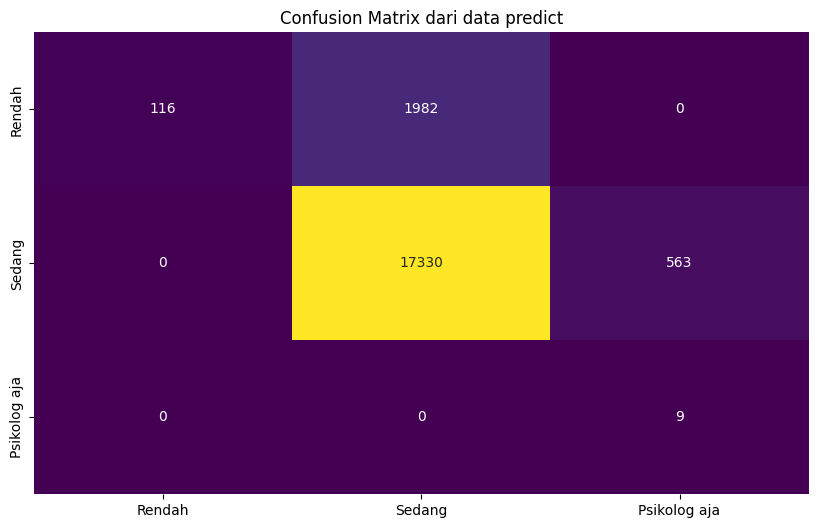

In [40]:
print('Confusion Matrix dari data predict')
plt.figure(figsize=(10, 6))
plt.title('Confusion Matrix dari data predict')
sns.heatmap(data=matrix, annot=True, fmt='.0f', xticklabels=label, yticklabels=label, cmap='viridis', cbar=False)
plt.show()

AKURASI DARI MODEL YANG TELAH DI TRAIN

In [41]:
total_benar = matrix[0][0] + matrix[1][1] + matrix[2][2]

acc = (total_benar / len(y_test))

acc = print(f"Akurasi dari model {acc * 100:.2f}%")

Akurasi dari model 87.28%


# Uji Coba Data Baru (Interface) |  Modul D

In [44]:
import tkinter as tk 
from tkinter import ttk, messagebox

FEATURE_COLUMNS = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity']

class GUI:
    def __init__(self,root,tabCtrl):
        self.root = root 
        self.tabCtrl = tabCtrl
        self.root.geometry("520x720")
        self.root.title("Check Your Stress Level")
        self.bg = '#e7eaeb'
        self.header_fonts = ("Segoe UI", 15, 'bold')
        self.form_fonts = ("Helvetica", 12, "bold")
        self.root.resizable(False, False)
        self.layouts()

    def layouts(self):
        tab1 = tk.Frame(self.tabCtrl, bg=self.bg)
        self.tabCtrl.add(tab1, text="Uji Coba Data")

        header = tk.Frame(tab1, borderwidth=1, height=50, bg="#37c466", relief='solid')
        header.pack(fill='x', padx=10, pady=20)
        tk.Label(header, text="PREDIKSI TINGKAT STRESS", font=self.header_fonts, fg='#FFFFFF', bg='#37c466').pack()

        form = tk.Frame(tab1, bg=self.bg)
        form.pack(fill='x', padx=10, pady=12)
        tk.Label(form, text="Durasi Jam Tidur /Hari", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        self.entry_sleep = tk.Entry(form, width=30)
        self.entry_sleep.pack(side='right')

        form = tk.Frame(tab1, bg=self.bg)
        form.pack(fill='x', padx=10, pady=12)
        tk.Label(form, text="Durasi Jam Belajar /Hari", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        self.entry_study = tk.Entry(form, width=30)
        self.entry_study.pack(side='right')

        form = tk.Frame(tab1, bg=self.bg)
        form.pack(fill='x', padx=10, pady=12)
        tk.Label(form, text="Durasi Bermain Sosial Media /Hari", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        self.entry_doomscroll = tk.Entry(form, width=30)
        self.entry_doomscroll.pack(side='right')

        form = tk.Frame(tab1, bg=self.bg)
        form.pack(fill='x', padx=10, pady=12)
        tk.Label(form, text="Menit aktifitas fisik /Minggu", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        self.entry_sports = tk.Entry(form, width=30)
        self.entry_sports.pack(side='right')

        frame_button = tk.Frame(tab1, bg=self.bg)
        frame_button.pack(fill='both', pady=10)
        submit = tk.Button(frame_button, text="CEK STRESS LEVEL", width=45,height=2, font=("Segoe UI", 10, "bold"), fg='white', bg="#1bb34e", command=self.process)
        submit.pack()

        frame_button = tk.Frame(tab1, bg=self.bg)
        frame_button.pack(fill='both', pady=2)
        clear = tk.Button(frame_button, text="CLEAR INPUT", width=45,height=2, font=("Segoe UI", 10, "bold"), fg='white', bg="#09a8d8", command=self.clear)
        clear.pack()
        #end tab1
        

        #tab 2
        tab2 = tk.Frame(self.tabCtrl, bg=self.bg)
        self.tabCtrl.add(tab2, text="Informasi Model")

        header2 = tk.Frame(tab2, bg="#13a5af", borderwidth=1, height=50, relief='solid')
        header2.pack(fill='x', pady=20, padx=10)
        tk.Label(header2, text="INFORMASI MODEL", font=self.header_fonts, fg='#FFFFFF', bg='#13a5af').pack()

        form2 = tk.Frame(tab2, bg=self.bg, relief="groove", borderwidth=1)
        form2.pack(fill='x', padx=5, pady=20)
        tk.Label(form2, text="Akurasi Model : ", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        tk.Label(form2, text=f"{total_benar / len(y_test)}", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='right')


        form2 = tk.Frame(tab2, bg=self.bg, relief="groove", borderwidth=1)
        form2.pack(fill='x', padx=5, pady=20)
        tk.Label(form2, text="Jumlah Data Train : ", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        tk.Label(form2, text='80%', bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='right')


        form2 = tk.Frame(tab2, bg=self.bg, relief="groove", borderwidth=1)
        form2.pack(fill='x', padx=5, pady=20)
        tk.Label(form2, text="Jumlah Data Test : ", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='left')
        tk.Label(form2, text="20%", bg=self.bg, fg="#24252a", font=self.form_fonts).pack(side='right')
        # end tab 2

    def clear(self):
        self.entry_sleep.delete(0, tk.END)
        self.entry_study.delete(0, tk.END)
        self.entry_doomscroll.delete(0, tk.END)
        self.entry_sports.delete(0, tk.END)
        self.entry_sleep.focus_set()
        return
    
    def _get_inputs(self):
        values = {
            "Sleep_Duration": self.entry_sleep.get().strip(),
            "Study_Hours": self.entry_study.get().strip(),
            "Social_Media_Hours": self.entry_doomscroll.get().strip(),
            "Physical_Activity": self.entry_sports.get().strip(),
        }
        if any(v == "" for v in values.values()):
            messagebox.showerror("Error", "Silahkan isi semua inputan")
            return None
        try:
            return {k: float(v) for k, v in values.items()}
        except ValueError:
            messagebox.showerror("Error", "Semua input harus berupa angka")
            return None
    
    def _normalize_features(self, df):
        denom = (X_MAX - X_MIN).replace(0, 1)
        return (df - X_MIN) / denom
    
    def process(self):
        values = self._get_inputs()
        if values is None:
            return
        df_baru = pd.DataFrame([values], columns=FEATURE_COLUMNS)
        df_baru = self._normalize_features(df_baru)
        pred = ln.predict(df_baru)
        pred_value = int(np.clip(np.round(pred[0]), 1, 10))
        deskripsi_map = {
            1: "Stress Level Anda Rendah, Sangat Baik, Tetap Jaga Pola Hidup Anda",
            2: "Stress Level Anda Rendah, Sangat Baik, Tetap Jaga Pola Hidup Anda",
            3: "Stress Level Anda Normal, Hindari Kebiasaan Buruk",
            4: "Stress Level Anda Normal, Hindari Kebiasaan Buruk",
            5: "Stress Level Anda Medium, Perbaiki Kebiasaan Buruk Anda!",
            6: "Stress Level Anda Cukup Tinggi, Perbaiki Kebiasaan Buruk Anda!",
            7: "Stress Level Anda Cukup Tinggi, Perbaiki Kebiasaan Buruk Anda!",
            8: "Stress Level Anda Tinggi, Perbaiki Pola Hidup Anda",
            9: "Stress Level Anda Sangat Tinggi, Anda Harus Segera Memperbaiki Kebiasaan Buruk Anda",
            10: "Stress Level Anda Sangat Tinggi, Anda Harus Segera Memperbaiki Kebiasaan Buruk Anda",
        }
        deskripsi = deskripsi_map.get(pred_value, "Hasil tidak tersedia")
        messagebox.showinfo("Informasi", f"Tingkatan Stress Anda : {pred_value}, {deskripsi}")


if __name__ == "__main__":
    root = tk.Tk()
    tabCtrl = ttk.Notebook(root)
    tabCtrl.pack(expand=True, fill='both')
    GUI(root, tabCtrl)
    root.mainloop()